# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan adalah **Breast Cancer Wisconsin (Diagnostic) Dataset** yang tersedia secara bawaan pada library scikit-learn (`sklearn.datasets.load_breast_cancer`), bersumber dari UCI Machine Learning Repository:  
   https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

2. **Informasi Umum**:
   - **Nama**: Breast Cancer Wisconsin (Diagnostic) Dataset
   - **Jumlah Data**: 569 baris, 30 fitur + 1 target
   - **Tipe Data**: Tabular / Structured Data
   - **Task**: Klasifikasi Biner (Binary Classification)
   - **Target**: `target` (0 = malignant/ganas, 1 = benign/jinak)
   - **Fitur**: 30 fitur numerik hasil pengukuran karakteristik sel inti tumor (radius, texture, perimeter, area, smoothness, dll)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [19]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [20]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')

Jumlah baris  : 569
Jumlah kolom  : 31


In [21]:
# Menampilkan 5 baris pertama
print('5 baris pertama dataset:')
df.head()

5 baris pertama dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [22]:
# Menampilkan 5 baris terakhir
print('5 baris terakhir dataset:')
df.tail()

5 baris terakhir dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [23]:
# Info lengkap dataset (tipe data + non-null count)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [24]:
# 4.1 Statistik Deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== STATISTIK DESKRIPTIF ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [25]:
# 4.2 Pengecekan Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
print('=== MISSING VALUES ===')
print(missing_df[missing_df['Jumlah Missing'] > 0] if missing.sum() > 0 else 'Tidak ada missing value pada dataset.')

=== MISSING VALUES ===
Tidak ada missing value pada dataset.


In [26]:
# 4.3 Pengecekan Data Duplikat
print('=== DATA DUPLIKAT ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== DATA DUPLIKAT ===
Jumlah baris duplikat: 0


=== DISTRIBUSI TARGET ===
target
1    357
0    212
Name: count, dtype: int64

Persentase:
target
1    62.74
0    37.26
Name: proportion, dtype: float64


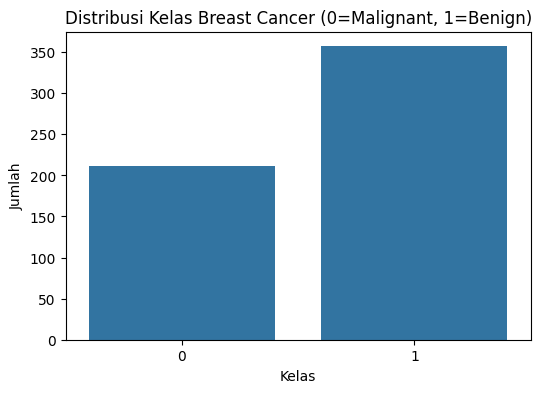

In [27]:
# 4.4 Distribusi Target
print('=== DISTRIBUSI TARGET ===')
print(df['target'].value_counts())
print('\nPersentase:')
print(df['target'].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Distribusi Kelas Breast Cancer (0=Malignant, 1=Benign)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

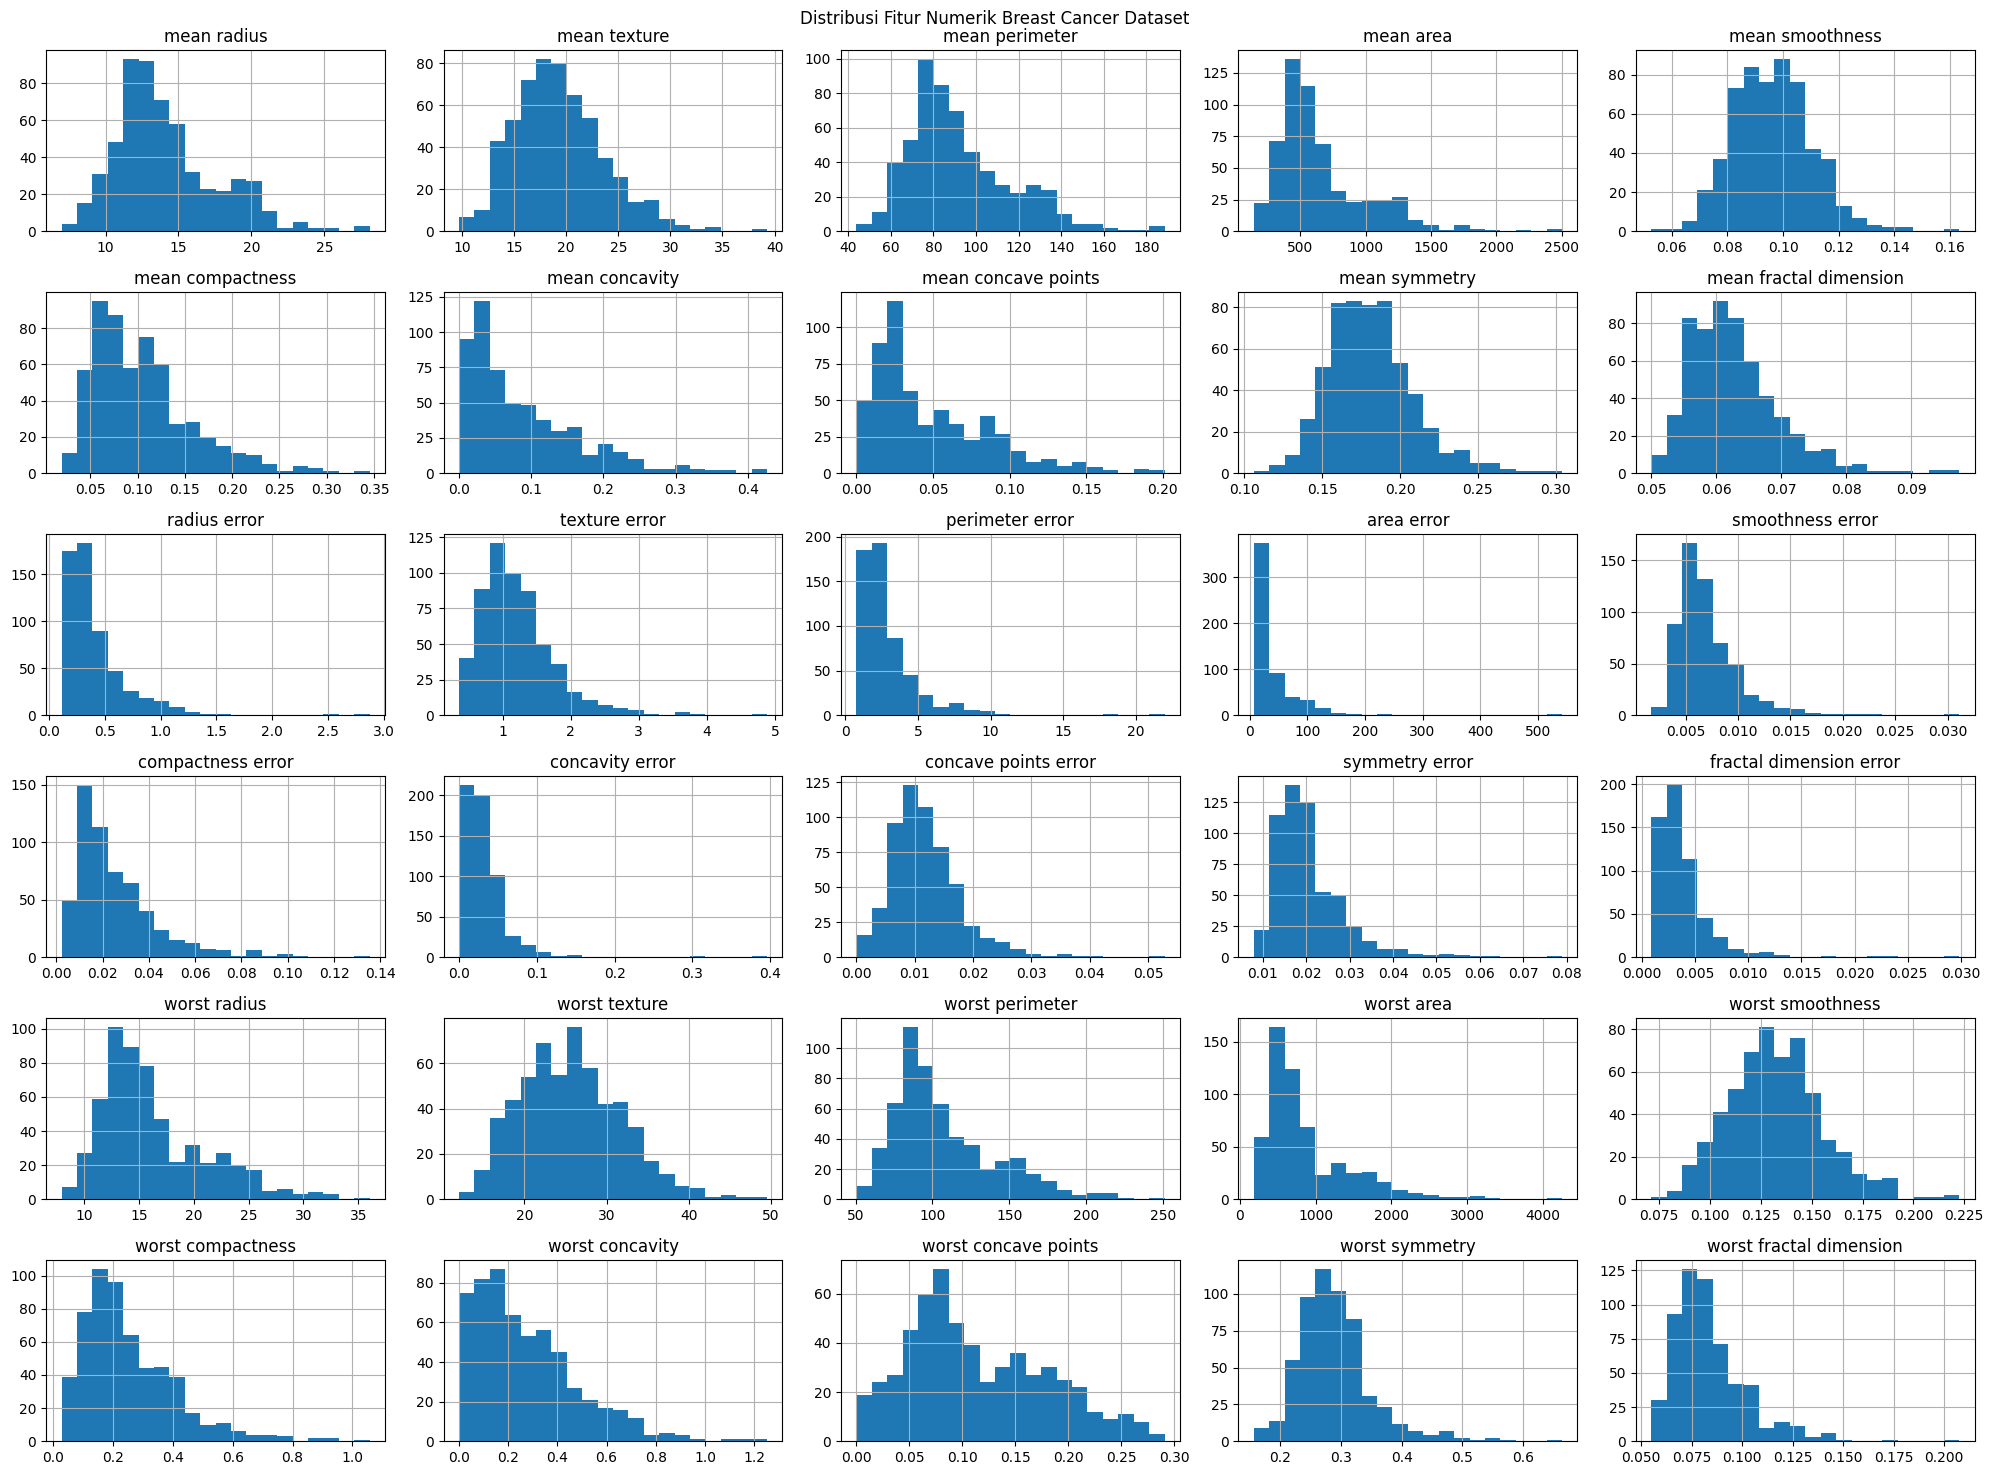

In [28]:
# 4.5 Distribusi Fitur Numerik
df.drop('target', axis=1).hist(figsize=(20,15), bins=20)
plt.suptitle('Distribusi Fitur Numerik Breast Cancer Dataset')
plt.tight_layout()
plt.show()

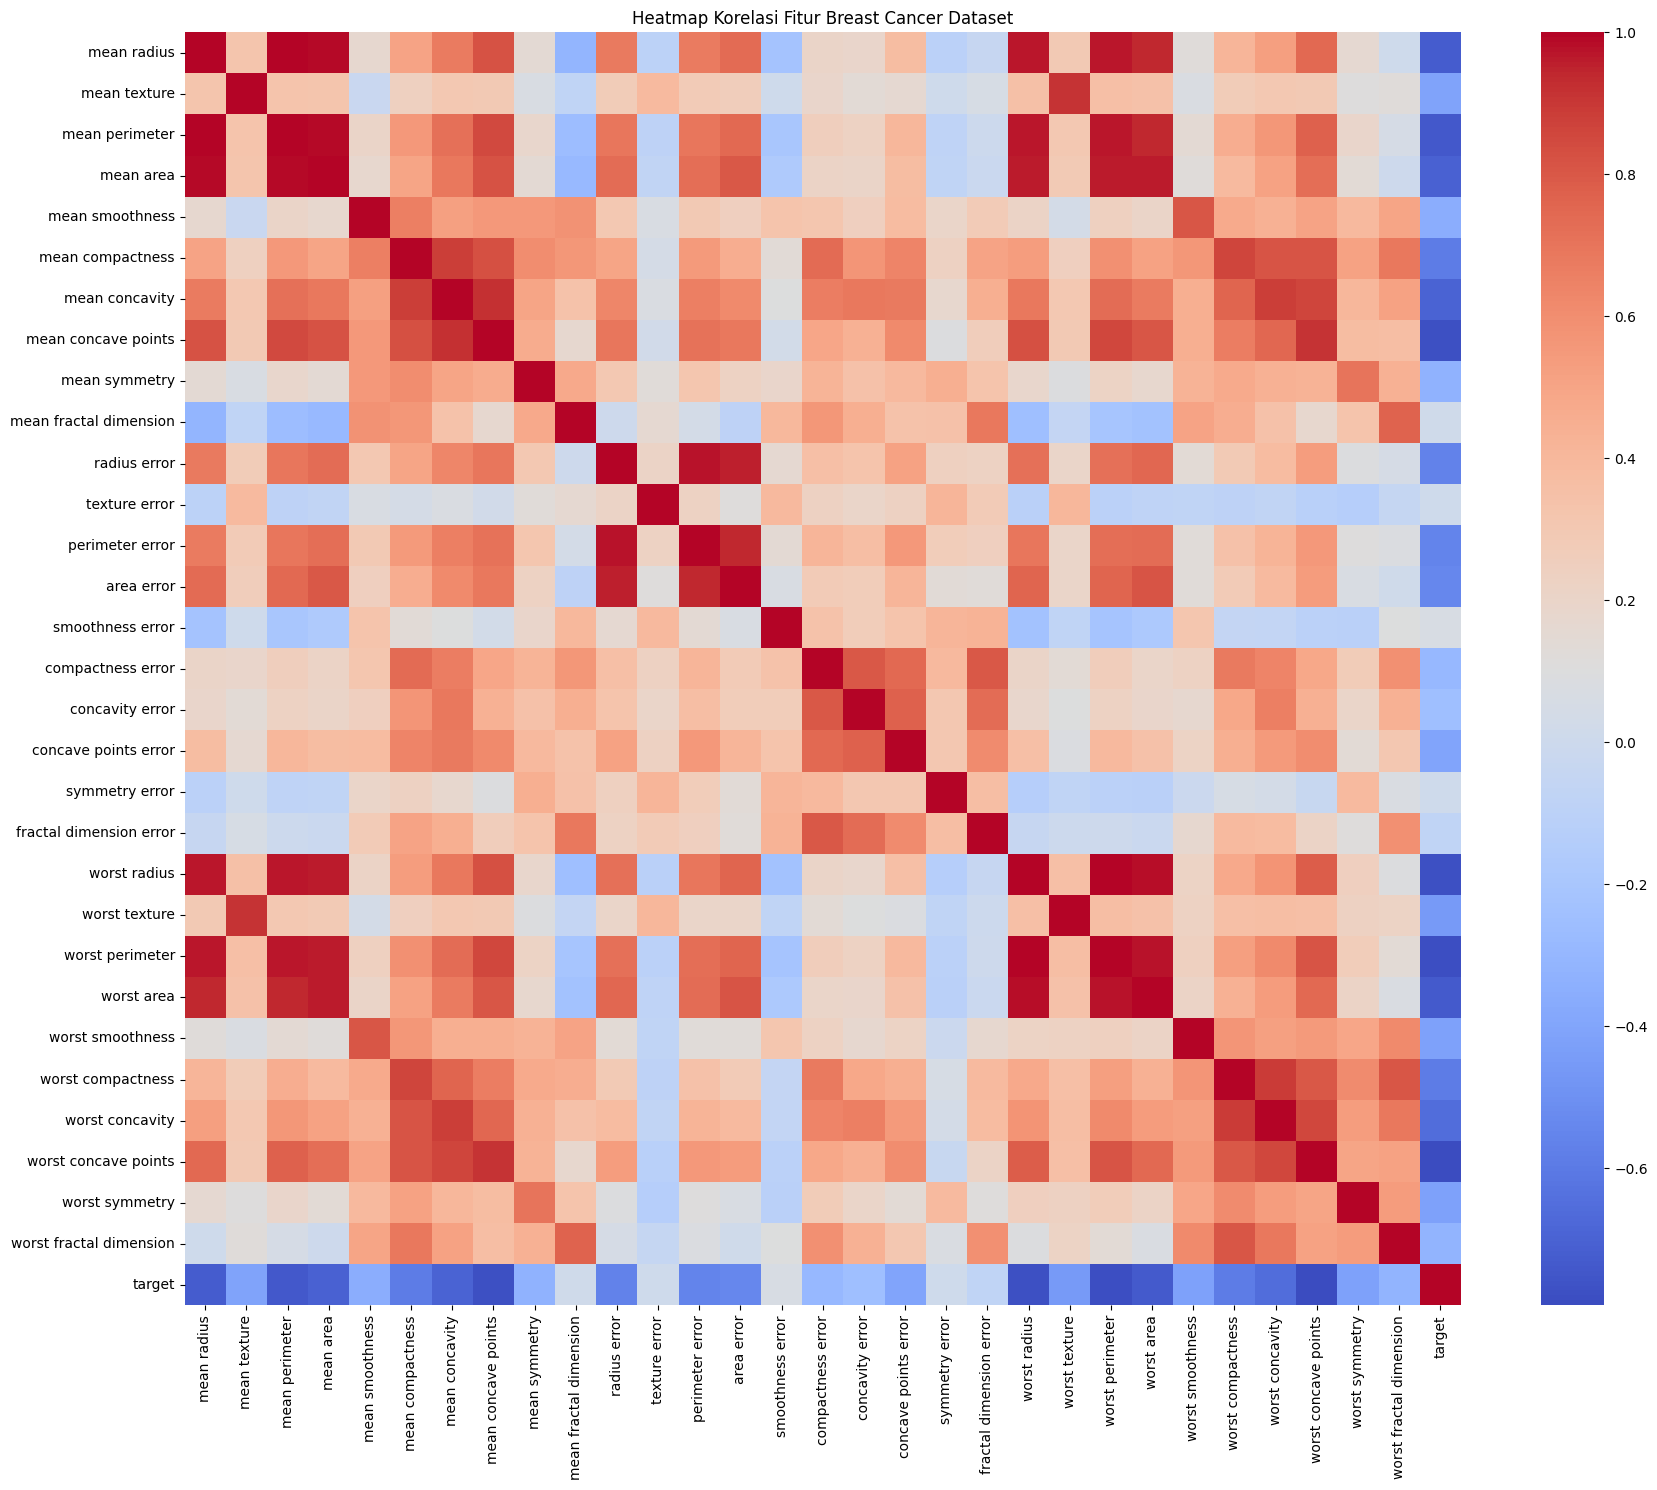

In [29]:
# 4.6 Heatmap Korelasi
plt.figure(figsize=(18,15))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur Breast Cancer Dataset')
plt.tight_layout()
plt.show()

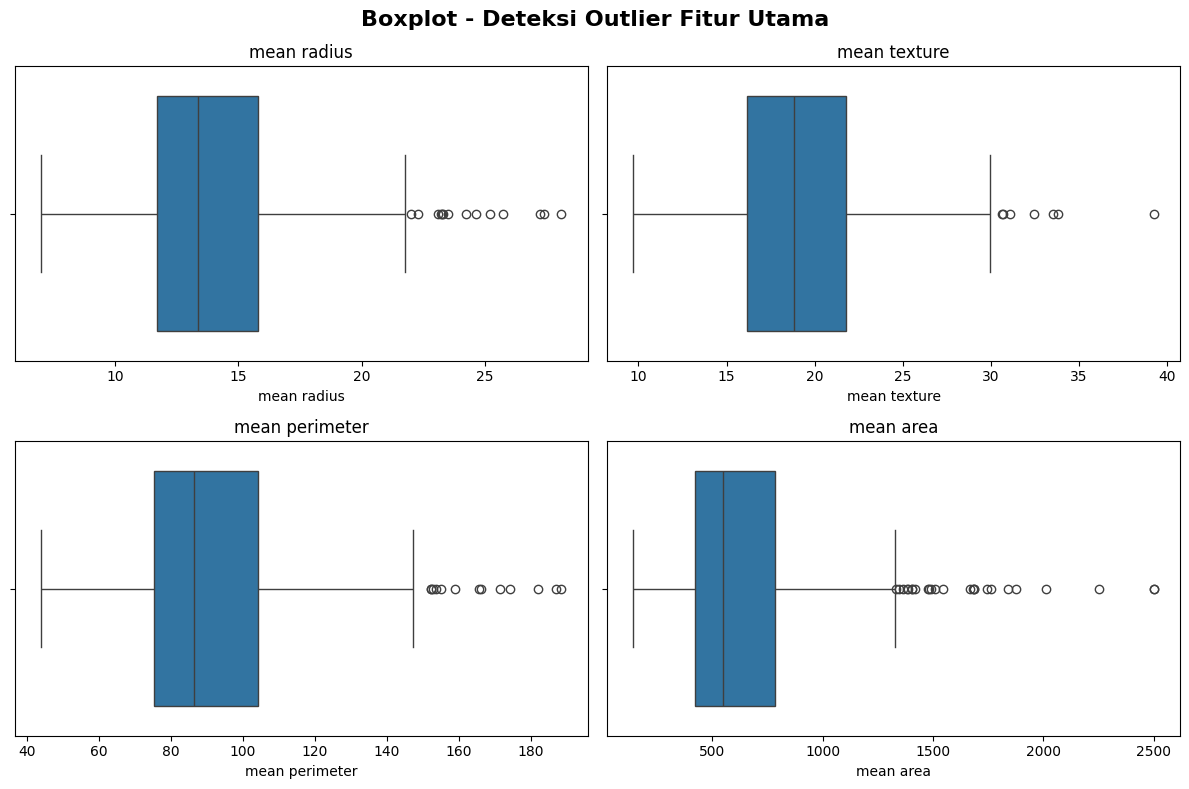

In [30]:
# 4.7 Deteksi Outlier dengan Boxplot (contoh beberapa fitur utama)
sample_cols = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Boxplot - Deteksi Outlier Fitur Utama', fontsize=16, fontweight='bold')

for i, col in enumerate(sample_cols):
    ax = axes[i // 2, i % 2]
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [31]:
# 5.1 Menyalin DataFrame agar data asli tidak berubah
df_processed = df.copy()
print('DataFrame berhasil disalin.')
print(f'Shape awal: {df_processed.shape}')

DataFrame berhasil disalin.
Shape awal: (569, 31)


In [32]:
# 5.2 Menghapus Data Duplikat (jika ada)
before = len(df_processed)
df_processed.drop_duplicates(inplace=True)
after = len(df_processed)

print('=== PENGHAPUSAN DUPLIKAT ===')
print(f'Baris sebelum : {before:,}')
print(f'Baris sesudah : {after:,}')
print(f'Baris dihapus : {before - after:,}')

=== PENGHAPUSAN DUPLIKAT ===
Baris sebelum : 569
Baris sesudah : 569
Baris dihapus : 0


In [33]:
# 5.3 Penanganan Outlier dengan IQR Clipping
feature_cols = df_processed.drop('target', axis=1).columns

print('=== PENANGANAN OUTLIER (IQR CLIPPING) ===')
for col in feature_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_processed[col] = df_processed[col].clip(lower=lower, upper=upper)

print('Outlier pada seluruh fitur numerik telah ditangani dengan metode IQR clipping.')

=== PENANGANAN OUTLIER (IQR CLIPPING) ===
Outlier pada seluruh fitur numerik telah ditangani dengan metode IQR clipping.


In [34]:
# 5.4 Split Data Train/Test
X = df_processed.drop('target', axis=1)
y = df_processed['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')

X_train shape: (455, 30)
X_test shape : (114, 30)


In [35]:
# 5.5 Standarisasi Fitur Numerik (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('=== HASIL STANDARISASI ===')
print(f'Mean (train, contoh fitur pertama)  : {X_train_scaled[:,0].mean():.4f}')
print(f'Std  (train, contoh fitur pertama)  : {X_train_scaled[:,0].std():.4f}')

=== HASIL STANDARISASI ===
Mean (train, contoh fitur pertama)  : 0.0000
Std  (train, contoh fitur pertama)  : 1.0000


In [36]:
# 5.6 Verifikasi Hasil Preprocessing & Simpan
print('=== RINGKASAN HASIL PREPROCESSING ===')
print(f'Shape X_train  : {X_train_scaled.shape}')
print(f'Shape X_test   : {X_test_scaled.shape}')
print(f'Missing values : {df_processed.isnull().sum().sum()}')

# Simpan hasil preprocessing
os.makedirs('breast_cancer_preprocessing', exist_ok=True)

pd.DataFrame(X_train_scaled, columns=X.columns).to_csv('breast_cancer_preprocessing/X_train.csv', index=False)
pd.DataFrame(X_test_scaled, columns=X.columns).to_csv('breast_cancer_preprocessing/X_test.csv', index=False)
y_train.to_csv('breast_cancer_preprocessing/y_train.csv', index=False)
y_test.to_csv('breast_cancer_preprocessing/y_test.csv', index=False)

print('\nPreprocessing selesai! File disimpan di folder breast_cancer_preprocessing/')

=== RINGKASAN HASIL PREPROCESSING ===
Shape X_train  : (455, 30)
Shape X_test   : (114, 30)
Missing values : 0

Preprocessing selesai! File disimpan di folder breast_cancer_preprocessing/
